In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 500
data = np.concatenate([
    np.random.normal(0, 1, n // 3),
    np.random.normal(5, 1, n // 3),
    np.random.normal(-2, 1, n // 3)
])


In [3]:
def segment_cost(segment):
    var = np.var(segment)
    length = len(segment)
    return length * np.log(var + 1e-6)  # +1e-6 to avoid log(0)

In [5]:
def mdl_segmentation(data, window_size=50, step=10, threshold=10):
    change_points = []
    i = 0
    while i + 2 * window_size <= len(data):
        left = data[i:i + window_size]
        right = data[i + window_size:i + 2 * window_size]
        full = np.concatenate([left, right])

        cost_full = segment_cost(full)
        cost_split = segment_cost(left) + segment_cost(right)

        # If the cost after splitting is lower by a margin (threshold), mark a change
        if cost_split + threshold < cost_full:
            change_point = i + window_size
            change_points.append(change_point)
            i += window_size  # jump to next window after change
        else:
            i += step  # slide window

    return change_points


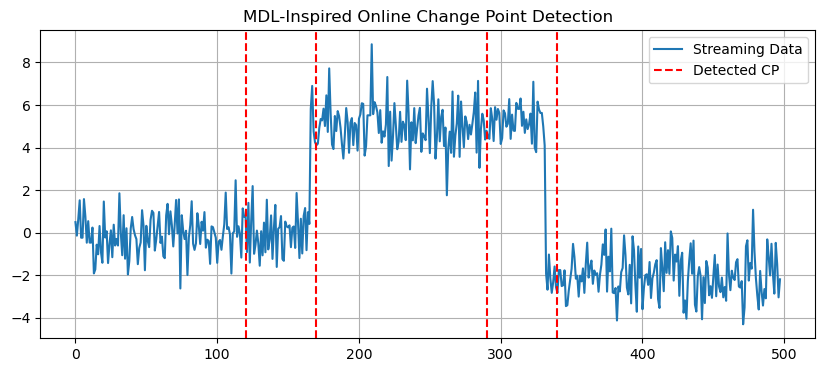

Change Points: [120, 170, 290, 340]


In [7]:
change_points = mdl_segmentation(data)

plt.figure(figsize=(10, 4))
plt.plot(data, label='Streaming Data')
for cp in change_points:
    plt.axvline(cp, color='red', linestyle='--', label='Detected CP' if cp == change_points[0] else "")
plt.legend()
plt.title("MDL-Inspired Online Change Point Detection")
plt.grid(True)
plt.show()

print("Change Points:", change_points)